# 🚀 The Ultimate Kaggle Starter Template (XGBoost Edition)
**Welcome to your competition journey!** This notebook is designed to take you from raw data to a submittable model using the industry-standard XGBoost algorithm.

> **Tip for Beginners:** Cells marked with `[EDIT REQUIRED]` are places where you'll need to change code to match your specific dataset. Everything else should work out of the box!

---

### 📑 Table of Contents
0. [Kaggle Auth & Download (Colab Only)](#auth)
1. [Environment & Library Imports](#setup)
2. [Data Loading & Inspection](#loading)
3. [Deep Exploratory Data Analysis (EDA)](#eda)
4. [Advanced Graphical Presentation](#viz)
5. [Preprocessing & Feature Engineering](#prep)
6. [Model Training with XGBoost](#modeling)
7. [Performance Evaluation](#eval)
8. [Submission Production](#submit)

<a id='auth'></a>
## 🔑 Step 0: Kaggle Authentication (Colab Only)

If you are running this on **Google Colab**, you need to give it access to your Kaggle account to download the data. 

**Instructions:**
1. Go to your Kaggle account settings and click **"Create New API Token"**. This downloads a `kaggle.json` file.
2. Run the cells below to upload that file.

In [2]:
# --- OPTION 1: Upload kaggle.json manually ---
try:
    from google.colab import files
    print("Please upload your kaggle.json file:")
    files.upload()
except ImportError:
    print("Not running in Colab. Skipping manual upload.")

Please upload your kaggle.json file:


KeyboardInterrupt: 

In [3]:
# --- OPTION 2: Use kaggle.json from Google Drive ---
# (Uncomment the lines below if you prefer to load from Drive)

from google.colab import drive
drive.mount('/content/drive')
!cp drive/MyDrive/kaggle.json .
!cp drive/MyDrive/kaggle.zip .
!if [ -f kaggle.json ]; then exit 1; fi; unzip kaggle.zip

Mounted at /content/drive


In [4]:
# --- Setting up the Kaggle Directory ---
!pip install -q kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("✅ Kaggle credentials configured!")

✅ Kaggle credentials configured!


In [7]:
# --- [EDIT REQUIRED] Download Dataset ---
COMPETITION_NAME = 'house-prices-advanced-regression-techniques' # Change 'titanic' to your competition name!

!kaggle competitions download -c {COMPETITION_NAME}
!unzip -o {COMPETITION_NAME}.zip # -o overwrites existing files

  0% 0.00/199k [00:00<?, ?B/s]
100% 199k/199k [00:00<00:00, 403MB/s]
Archive:  house-prices-advanced-regression-techniques.zip
  inflating: data_description.txt    
  inflating: sample_submission.csv   
  inflating: test.csv                
  inflating: train.csv               


<a id='setup'></a>
## 🛠 1. Environment & Library Imports

To build a model, we need several tools:
*   `pandas` & `numpy` for handling data tables.
*   `matplotlib` & `seaborn` for drawing graphs.
*   `xgboost` for the powerful Extreme Gradient Boosting model.

In [8]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

# Machine Learning libraries
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Settings to make it look pretty
%matplotlib inline
plt.style.use('fivethirtyeight')
sns.set_palette("viridis")
warnings.filterwarnings('ignore') # Hides annoying warnings
pd.set_option('display.max_columns', None) # Show all columns in tables

print("🚀 Global settings initialized. Ready for analysis.")

🚀 Global settings initialized. Ready for analysis.


<a id='loading'></a>
## 📁 2. Data Loading & Inspection

In Kaggle, you usually get two files:
1.  **Train (`train.csv`)**: Data used to teach the model (includes the answers).
2.  **Test (`test.csv`)**: Data where you need to predict the answers.

In [12]:
# Try to load the data
try:
    train_df = pd.read_csv('train.csv')
    test_df = pd.read_csv('test.csv')
    print(f"✅ Success! Found {len(train_df)} training rows and {len(test_df)} testing rows.")
except FileNotFoundError:
    print("❌ Files not found! Did you run Step 0 or upload the CSVs?")
    train_df = test_df = None

if train_df is not None:
    display(train_df) # Show the first 3 rows

✅ Success! Found 1460 training rows and 1459 testing rows.


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1999,2000,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,Unf,0,Unf,0,953,953,GasA,Ex,Y,SBrkr,953,694,0,1647,0,0,2,1,3,1,TA,7,Typ,1,TA,Attchd,1999.0,RFn,2,460,TA,TA,Y,0,40,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,6,1978,1988,Gable,CompShg,Plywood,Plywood,Stone,119.0,TA,TA,CBlock,Gd,TA,No,ALQ,790,Rec,163,589,1542,GasA,TA,Y,SBrkr,2073,0,0,2073,1,0,2,0,3,1,TA,7,Min1,2,TA,Attchd,1978.0,Unf,2,500,TA,TA,Y,349,0,0,0,0,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,9,1941,2006,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,Ex,Gd,Stone,TA,Gd,No,GLQ,275,Unf,0,877,1152,GasA,Ex,Y,SBrkr,1188,1152,0,2340,0,0,2,0,4,1,Gd,9,Typ,2,Gd,Attchd,1941.0,RFn,1,252,TA,TA,Y,0,60,0,0,0,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1950,1996,Hip,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,TA,TA,Mn,GLQ,49,Rec,1029,0,1078,GasA,Gd,

<a id='eda'></a>
## 📊 3. Exploratory Data Analysis (EDA)

Before building a model, we must "meet" the data. We check for **Missing Values** (NaNs) and see what the numbers look like.

In [11]:
if train_df is not None:
    print("--- Data Types & Non-Null Counts ---")
    print(train_df.info())
    
    print("\n--- Statistical Overview ---")
    display(train_df.describe().T)
    
    print("\n--- Missing Values Count ---")
    nulls = train_df.isnull().sum()
    print(nulls[nulls > 0])

--- Data Types & Non-Null Counts ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0



--- Missing Values Count ---
LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64


<a id='viz'></a>
## 🎨 4. Advanced Graphical Presentation

Pictures are easier to understand than numbers. 
1.  **Left Graph:** Shows the distribution of the thing we want to predict (the Target).
2.  **Right Graph:** Shows how different features relate to each other (Correlation).

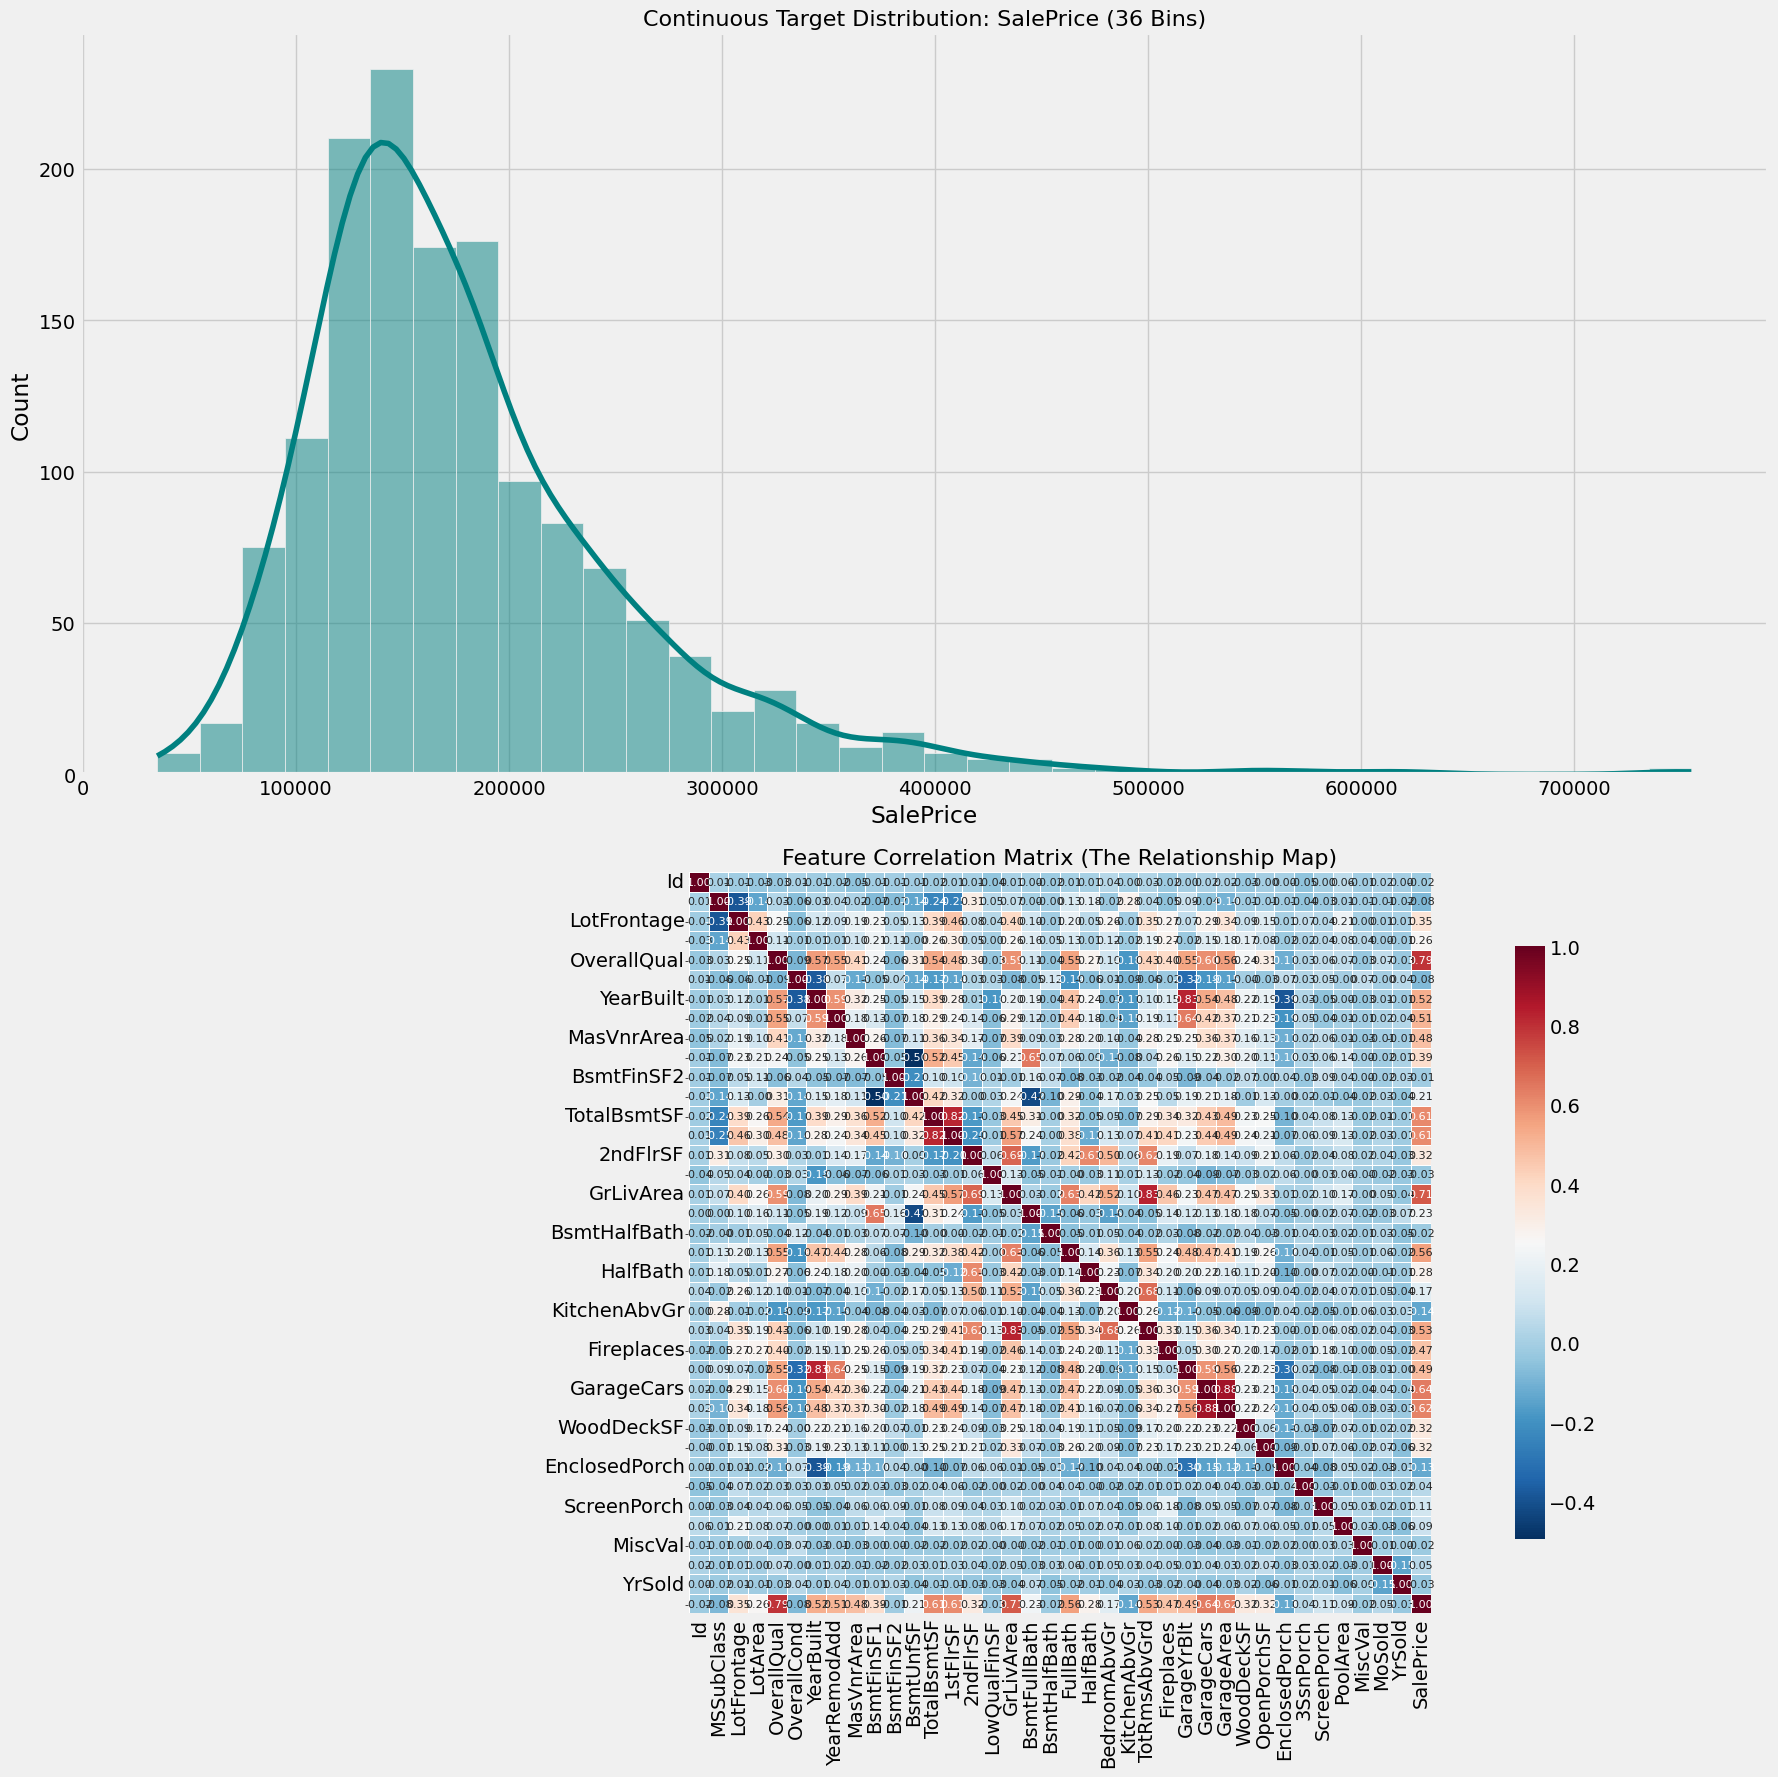

In [ ]:
if train_df is not None:
    # [EDIT REQUIRED] Update target_name to your Target column!
    target_name = 'SalePrice'
    
    # Dynamic Layout: Large format to handle many parameters
    plt.figure(figsize=(18, 18)) # Square base for high-impact viewing
    
    # --- 1. Subplot: Target Distribution ---
    plt.subplot(2, 1, 1)
    unique_vals = train_df[target_name].nunique()
    
    # If target is numeric and has many values, we treat it as continuous (float)
    if pd.api.types.is_numeric_dtype(train_df[target_name]) and unique_vals > 35:
        sns.histplot(train_df[target_name], bins=36, kde=True, color='teal')
        plt.title(f'Continuous Target Distribution: {target_name} (36 Bins)', fontsize=16)
    else:
        sns.countplot(data=train_df, x=target_name, palette='viridis')
        plt.title(f'Categorical Target Distribution: {target_name}', fontsize=16)
    
    
    plt.tight_layout()
    plt.show()

In [ ]:
if train_df is not None:
    numeric_cols = train_df.select_dtypes(include=[np.number])
    
    # Huge Square Figure for clarity
    plt.figure(figsize=(25, 25))
    
    # Calculate correlation
    corr = numeric_cols.corr()
    
    # Plotting
    sns.heatmap(corr, 
                annot=True, 
                cmap='RdBu_r', 
                fmt='.2f', 
                square=True, 
                linewidths=1.0, 
                cbar_kws={"shrink": .8},
                annot_kws={"size": 12, "weight": "bold"}) # Bigger, bolder fonts
    
    plt.title('The Feature Relationship Map', fontsize=30, pad=30)
    plt.xticks(fontsize=16, rotation=90)
    plt.yticks(fontsize=16)
    
    plt.show()

<a id='prep'></a>
## 🛠 5. Preprocessing & Feature Engineering

Machine Learning models don't like text (like "Male"/"Female") or missing values. 
We use a **Pipeline** to automatically:
1.  Fill in missing numbers with the **Median**.
2.  Turn text categories into **Numbers** (One-Hot Encoding).
3.  Scale numbers so they are all in the same range.

In [ ]:
def clean_and_feature(df, is_train=False):
    """Local function for custom edits to your data."""
    df = df.copy()
    
    # 1. Missing value indicators
    for col in df.columns:
        if df[col].isnull().any():
            df[f"{col}_isMissing"] = df[col].isnull().astype(int)
    
    # Let's drop columns that are too uninformative
    # Drops IDs and text-heavy
    drops = [c for c in ['Id', 'Name', 'Ticket', 'Cabin'] if c in df.columns]
    if len(drops) > 0:
        print(f"Dropping basic id columns: {drops}")
        df = df.drop(columns=drops)

    # 2. Drop low correlation numeric columns (only using train data for corr)
    # We will use the global `train_df` and `target_name` if possible, but safely.
    # To do this safely for both train and test, we should calculate drops once based on train_df
    # We can do that by referencing `train_df` and `target_name` from the global scope.
    global train_df, target_name
    
    if target_name in df.columns:
        # We are training
        corr_drops = []
        for col in df.select_dtypes(include=['int64', 'float64']).columns:
            if col != target_name:
                corr = df[col].corr(df[target_name])
                if abs(corr) < 0.05:
                    corr_drops.append(col)
        
        if len(corr_drops) > 0:
            print(f"Dropping low correlation (< 0.05) numeric columns: {corr_drops}")
            df = df.drop(columns=corr_drops)
            # Save for test set
            global _saved_corr_drops
            _saved_corr_drops = corr_drops
    else:
        # We are testing
        try:
            if len(_saved_corr_drops) > 0:
                drops_here = [c for c in _saved_corr_drops if c in df.columns]
                df = df.drop(columns=drops_here)
        except NameError:
            pass
            
    # 3. Object uniqueness
    # If unqiue values > 0.5 * total -> drop
    # Else if < 0.05 * total -> process them (keep them as is so OneHotEncoder will handle them)
    # Note: the user text says "If a object has unique value less than 0.05 * total, process them if a object value has unique value greater than 0.5 * total, drop them."
    obj_drops = []
    total_rows = len(df)
    for col in df.select_dtypes(include=['object']).columns:
        num_unique = df[col].nunique()
        if num_unique > 0.5 * total_rows:
            obj_drops.append(col)
        else:
            # We keep it to process
            pass
            
    if len(obj_drops) > 0:
        print(f"Dropping high-cardinality object columns (> 50% unique): {obj_drops}")
        df = df.drop(columns=obj_drops)
        
    return df

if train_df is not None:
    train_clean = clean_and_feature(train_df)
    
    # Define which columns are numbers and which are categories
    num_features = train_clean.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.drop(target_name)
    cat_features = train_clean.select_dtypes(include=['object']).columns

    # --- Automatic Processing Engine ---
    num_proc = Pipeline([('imputer', SimpleImputer(strategy='median')), 
                         ('scaler', StandardScaler())])
                         
    cat_proc = Pipeline([('imputer', SimpleImputer(strategy='constant', fill_value='NA')),
                         ('ohe', OneHotEncoder(handle_unknown='ignore'))])

    transformer = ColumnTransformer(transformers=[
        ('num', num_proc, num_features),
        ('cat', cat_proc, cat_features)
    ])
    
    print("✅ Processing engine is ready!")

<a id='modeling'></a>
## 🤖 6. Model Training with XGBoost

XGBoost is the winning algorithm for most Kaggle tabular competitions. It uses "Gradient Boosting" to improve from its mistakes step-by-step.

In [ ]:
if train_df is not None:
    # Separate the data (X) from the answer (y)
    X = train_clean.drop(columns=[target_name])
    y = train_clean[target_name]

    # --- XGBoost Parameters Explained ---
    xgb_params = {
        'n_estimators': 500,        # How many trees to build. More = more complex model.
        'learning_rate': 0.05,     # Step size. Smaller values make training slower but more precise.
        'max_depth': 6,            # How deep each tree can go. Higher = more prone to overfitting.
        'subsample': 0.8,          # Fraction of rows used for each tree (prevents overfitting).
        'colsample_bytree': 0.8,   # Fraction of columns used for each tree.
        'random_state': 42,
        
        # --- GPU Acceleration ---
        # Uncomment the line below to use Kaggle/Colab GPU (requires GPU runtime enabled)
        # 'tree_method': 'gpu_hist'
    }

    # Create a Master Pipeline (Process Data -> Predict Answer)
    final_model = Pipeline([
        ('prep', transformer),
        ('model', xgb.XGBClassifier(**xgb_params))
    ])

    # Split data to test the model before submitting
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

    # Learn from the training data
    final_model.fit(X_train, y_train)
    
    print(f"✅ XGBoost training finished!")

<a id='eval'></a>
## 🔍 7. Performance Evaluation

How well did we do? We check the accuracy score and the **Confusion Matrix** to see where the model got confused.

In [ ]:
if train_df is not None:
    y_pred = final_model.predict(X_val)
    
    acc = accuracy_score(y_val, y_pred)
    print(f"🎯 Validation Accuracy: {acc:.2%}")
    
    # Visualization: heatmap of success vs failure
    plt.figure(figsize=(6, 5))
    sns.heatmap(confusion_matrix(y_val, y_pred), annot=True, fmt='d', cmap='Greens')
    plt.xlabel('Prediction')
    plt.ylabel('Actual Truth')
    plt.show()

<a id='submit'></a>
## 📤 8. Submission Production

Final Step! Apply the same logic to the `test.csv` file and save it to a file that Kaggle accepts.

In [ ]:
if test_df is not None:
    # Clean the test data the same way as train data
    test_clean = clean_and_feature(test_df)
    
    # Predict!
    predictions = final_model.predict(test_clean)
    
    # Create the submission file
    submission_file = pd.DataFrame({
        "PassengerId": test_df.iloc[:, 0], # Usually the first column is the ID
        target_name: predictions
    })

    submission_file.to_csv('submission.csv', index=False)
    print("🎉 DONE! 'submission.csv' is ready to be uploaded to Kaggle.")